# **PROBLEM STATMENT** - finding why employee attribution on higerside in organization

import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("/content/HR_EMPLYOEE_ATTRITION.csv")

In [ ]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.shape

(1470, 35)

In [ ]:
pd.set_option('display.max_rows', None)



In [ ]:
pd.set_option('display.max_columns', None)


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


# **Handling null values**

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


**finding duplicate values and remove it**

In [ ]:
df.duplicated().sum()

np.int64(0)

# **categorical columns**

In [ ]:
categorical_column=df.select_dtypes(include=['object']).columns

#**numerical_columns**

In [ ]:
numerical_columns = df.select_dtypes(include=['int64','float64'])

In [ ]:
numerical_columns

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
categorical_column

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

#**finding value count**

In [ ]:
for col in categorical_column:
  df_cat=df.value_counts(col)
  print("values of counts: ",df_cat)
  print("--"*100)


values of counts:  Attrition
No     1233
Yes     237
Name: count, dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
values of counts:  BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
values of counts:  Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
values of counts:  EducationField


#NOT FINDING ANY ERROR VALUE

#**finding outliers**

In [ ]:
for num in numerical_columns:
  q1=df[num].quantile(0.25)
  q3=df[num].quantile(0.75)
  iqr=q3-q1
  Lower_bound=q1-1.5*iqr
  Upper_bound=q3+1.5*iqr
  outliers=df[(df[num]<Lower_bound) | (df[num]>Upper_bound)]
  df=df[(df[num]>=Lower_bound) & (df[num]<=Upper_bound)] # remove of outliers
 # print("outliers: ",outliers)
  print("df :",df)
  print("--"*100)


df :       Age Attrition     BusinessTravel  DailyRate              Department  \
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
5      32        No  Travel_Frequently       1005  Research & Development   
11     29        No      Travel_Rarely        153  Research & Development   
12     31        No      Travel_Rarely        670  Research & Development   
...   ...       ...                ...        ...                     ...   
1463   31        No         Non-Travel        325  Research & Development   
1464   26        No      Travel_Rarely       1167                   Sales   
1465   36        No  Travel_Frequently        884  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
2  

In [ ]:
df.shape

(471, 35)

**Label encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
lb_dict={}

In [ ]:
for col in categorical_column:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  lb_dict[col]=le

In [ ]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
13,34,0,2,1346,1,19,2,3,1,18,...,3,80,1,3,2,3,2,2,1,2
14,28,1,2,103,1,24,3,1,1,19,...,2,80,0,6,4,3,4,2,0,3
17,22,0,0,1123,1,16,2,3,1,22,...,2,80,2,1,2,2,1,0,0,0
19,38,0,2,371,1,2,3,1,1,24,...,3,80,0,6,3,3,3,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1459,29,0,2,1378,1,13,2,4,1,2053,...,1,80,1,10,2,3,4,3,0,3
1460,29,0,2,468,1,28,4,3,1,2054,...,2,80,0,5,3,1,5,4,0,4
1464,26,0,2,1167,2,5,3,4,1,2060,...,4,80,0,5,2,3,4,2,0,0
1465,36,0,1,884,1,23,2,3,1,2061,...,3,80,1,17,3,3,5,2,0,3


# **delecting unique columns**

In [ ]:
df.drop(columns=['EmployeeCount','Over18'],axis='columns')

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,1,2,1373,1,2,2,4,4,4,...,2,80,0,7,3,3,0,0,0,0
13,34,0,2,1346,1,19,2,3,18,2,...,3,80,1,3,2,3,2,2,1,2
14,28,1,2,103,1,24,3,1,19,3,...,2,80,0,6,4,3,4,2,0,3
17,22,0,0,1123,1,16,2,3,22,4,...,2,80,2,1,2,2,1,0,0,0
19,38,0,2,371,1,2,3,1,24,4,...,3,80,0,6,3,3,3,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1459,29,0,2,1378,1,13,2,4,2053,4,...,1,80,1,10,2,3,4,3,0,3
1460,29,0,2,468,1,28,4,3,2054,4,...,2,80,0,5,3,1,5,4,0,4
1464,26,0,2,1167,2,5,3,4,2060,4,...,4,80,0,5,2,3,4,2,0,0
1465,36,0,1,884,1,23,2,3,2061,3,...,3,80,1,17,3,3,5,2,0,3


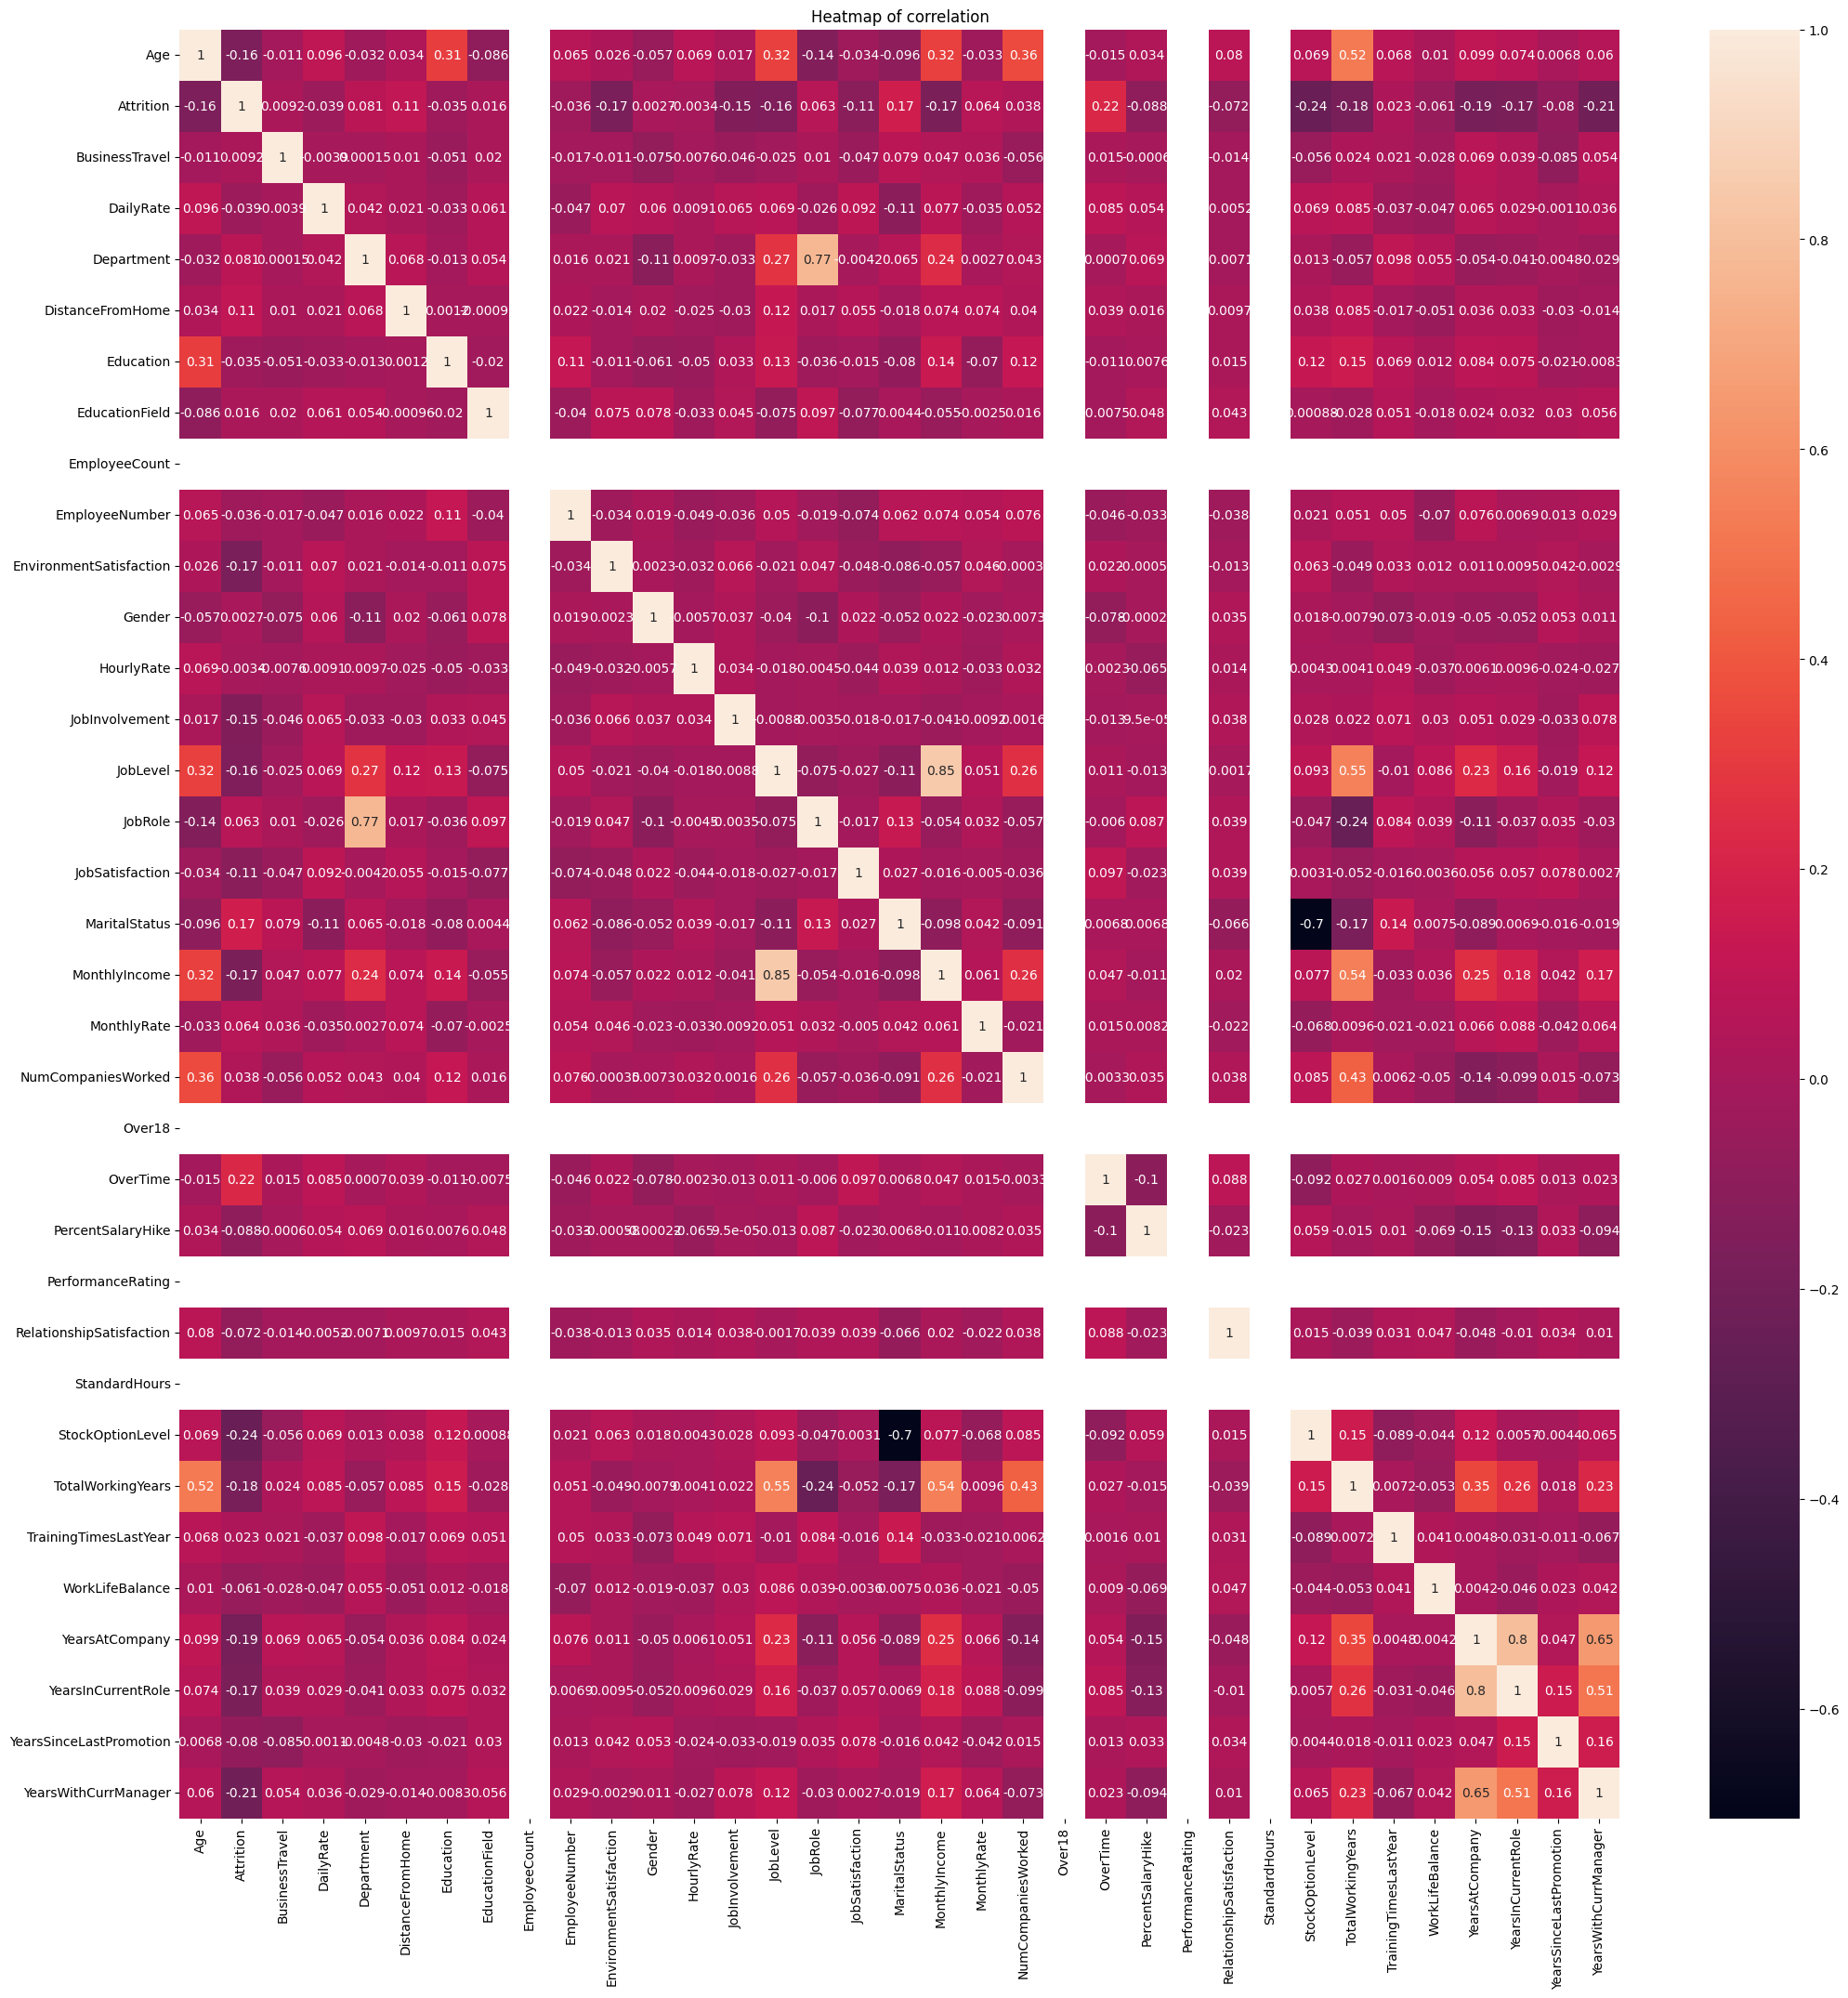

In [ ]:
plt.figure(figsize=(25,25))
sns.heatmap(df.corr(), annot=True)
plt.title("Heatmap of correlation")
plt.show()

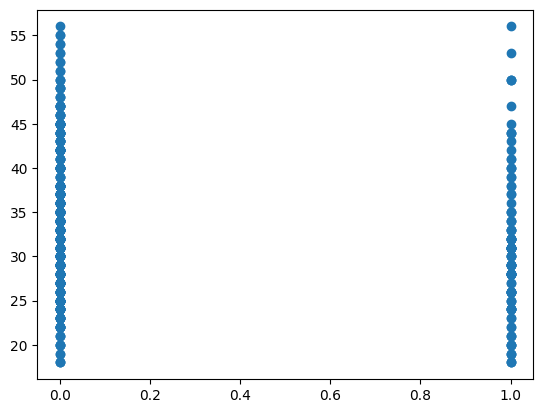

In [ ]:
plt.scatter("Attrition","Age",data=df)


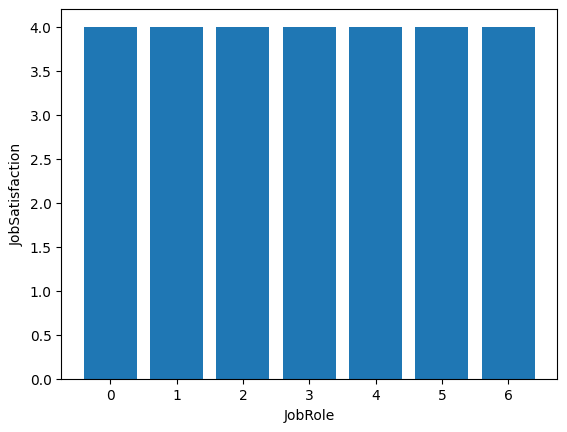

In [ ]:
plt.bar("JobRole","JobSatisfaction",data=df)
plt.xlabel("JobRole")
plt.ylabel("JobSatisfaction")
plt.show()

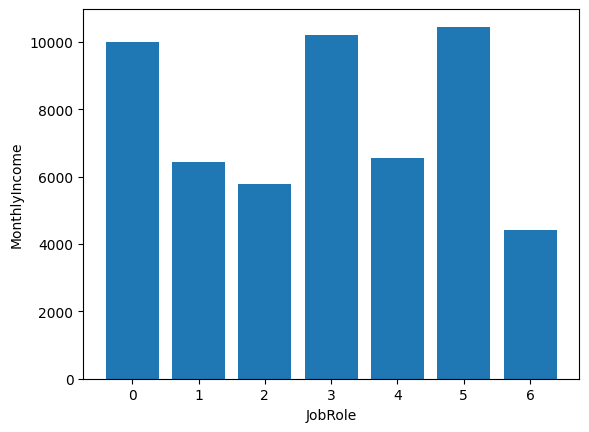

In [ ]:
plt.bar("JobRole","MonthlyIncome",data=df)
plt.xlabel("JobRole")
plt.ylabel("MonthlyIncome")
plt.show()

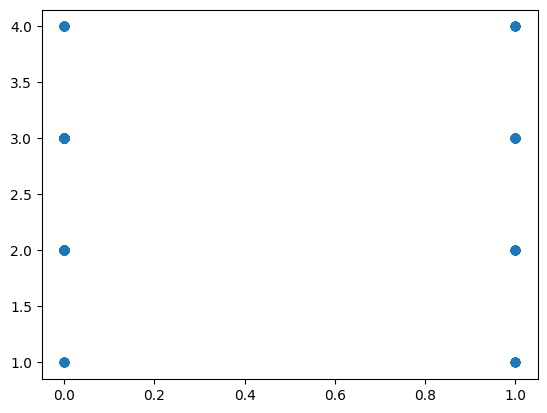

In [ ]:
plt.scatter("Attrition","WorkLifeBalance",data=df)
plt.show()


# **moldule buliding**

In [ ]:
from  sklearn.model_selection import train_test_split


# **this is create two variables for train data pattern**

In [ ]:
X=df.drop('Attrition',axis=1)
y=df['Attrition']


# **controller get train on 80 percent data and 20 percent for test controller**

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((376, 34), (95, 34), (376,), (95,))

#**import multiple models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# **Train the model**

In [ ]:
lr=LogisticRegression()
nb=GaussianNB()
rf=RandomForestClassifier()
dt=DecisionTreeClassifier()

In [ ]:
lr.fit(X_train,y_train)
nb.fit(X_train,y_train)
rf.fit(X_train,y_train)
dt.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


DecisionTreeClassifier()

# **model evalutaion**

In [ ]:
lr_predict=lr.predict(X_test)
nb_predict=nb.predict(X_test)
rf_predict=rf.predict(X_test)
dt_predict=dt.predict(X_test)

# now we can predict for differnt models what will be the output prediction

# confusion matrix

In [ ]:
print("confusion matrix for naive_bayes")
print(metrics.confusion_matrix(y_test,nb_predict))

confusion matrix for naive_bayes
[[68 10]
 [ 8  9]]


In [ ]:
print("confusion matrix for RandomForestClassifier")
print(metrics.confusion_matrix(y_test,rf_predict))

confusion matrix for RandomForestClassifier
[[75  3]
 [13  4]]


In [ ]:
print("confusion matrix for DecisionTreeClassifier")
print(metrics.confusion_matrix(y_test,dt_predict))

confusion matrix for DecisionTreeClassifier
[[61 17]
 [11  6]]


# **Finding of accuracy**

In [ ]:
nb_accuracy=metrics.precision_score(y_test,nb_predict)
rf_accuracy=metrics.recall_score(y_test,nb_predict)
dt_accuracy=metrics.f1_score(y_test,nb_predict)

In [ ]:
print("best accuracy",nb_accuracy)
print("best accuracy",rf_accuracy)
print("best accuracy",dt_accuracy)

best accuracy 0.47368421052631576
best accuracy 0.5294117647058824
best accuracy 0.5
